# E-Commerce Fraud Detection — IT9201 Project

**Course:** Machine Learning and Data Mining (IT9201)  
**Programme:** Master of Science in Artificial Intelligence  
**Institution:** Bahrain Polytechnic  
**Lecturer:** Dr. Shomona Gracia Jacob

---

## Project Overview
This notebook implements **fraud detection on e-commerce transactions** using three supervised machine learning models:
1. **Logistic Regression** 
2. **Naive Bayes**
3. **Random Forest** 

**Dataset:** [E-Commerce Fraud Detection Dataset (Kaggle)](https://www.kaggle.com/datasets/umuttuygurr/e-commerce-fraud-detection-dataset)


## 1. Library Imports & Setup
We import all required libraries for data manipulation, visualization, machine learning, and evaluation.

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time

# --- Scikit-learn ---
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import resample

# --- Imbalanced-learn ---
from imblearn.over_sampling import SMOTE

# --- Settings ---
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

print("All libraries imported successfully!")
print(f"NumPy version : {np.__version__}")
print(f"Pandas version: {pd.__version__}")

All libraries imported successfully!
NumPy version : 2.1.3
Pandas version: 2.2.3


## 2. Data Loading & Initial Exploration

In [2]:
DATA_PATH = "ecommerce_fraud.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset loaded successfully")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully
Shape: 299,695 rows × 17 columns

First 5 rows:


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [3]:
# Dataset structure
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-nul

In [4]:
# Statistical summary of numeric columns
df.describe()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


## 3. Exploratory Data Analysis (EDA)

In [5]:
# Set the target column
TARGET_COL = 'is_fraud'
print(f"Target column: '{TARGET_COL}'")

Target column: 'is_fraud'


Class Distribution:
  Non-Fraud (0):    293,083 (97.79%)
  Fraud     (1):      6,612 (2.21%)

Class imbalance ratio: 1 : 44.3


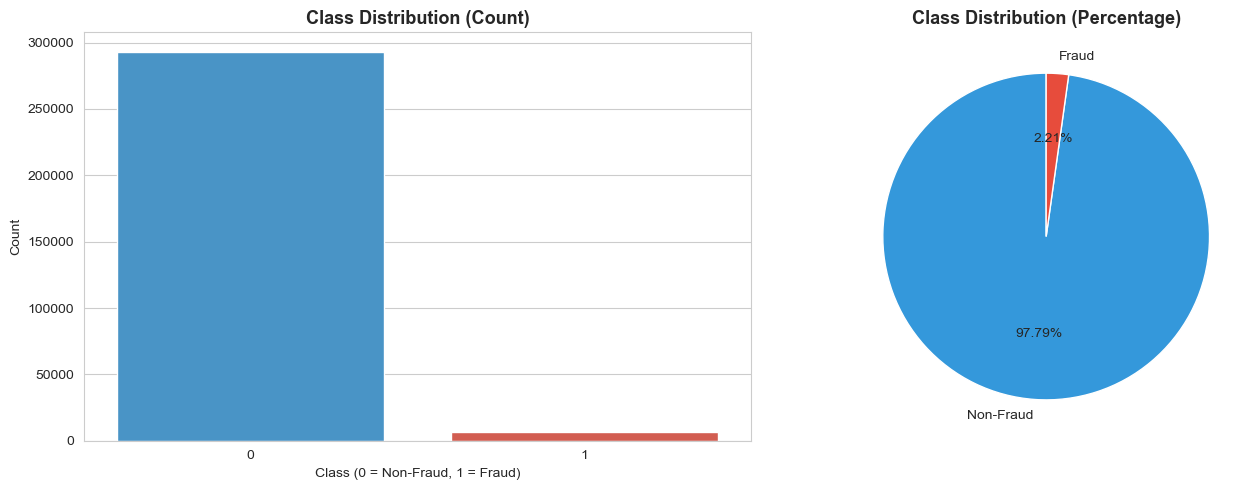

In [6]:
# Class distribution
class_counts = df[TARGET_COL].value_counts()
class_pct = df[TARGET_COL].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Non-Fraud (0): {class_counts.get(0, 0):>10,} ({class_pct.get(0, 0):.2f}%)")
print(f"  Fraud     (1): {class_counts.get(1, 0):>10,} ({class_pct.get(1, 0):.2f}%)")
print(f"\nClass imbalance ratio: 1 : {class_counts[0]/class_counts[1]:.1f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x=TARGET_COL, data=df, ax=axes[0], palette=['#3498db', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class (0 = Non-Fraud, 1 = Fraud)')
axes[0].set_ylabel('Count')

axes[1].pie(class_counts.values, labels=['Non-Fraud', 'Fraud'],
            autopct='%1.2f%%', colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Data Pre-processing & Feature Engineering
- Drop irrelevant ID columns (high cardinality, no predictive value)
- Handle datetime features (extract hour, day, month)
- Encode categorical variables 

In [7]:
# Make a copy
df_processed = df.copy()

# Step 1: Drop ID-type columns (no predictive value) 
id_like_cols = []
for col in df_processed.columns:
    if 'id' in col.lower() and col != TARGET_COL:
        if df_processed[col].nunique() > 0.95 * len(df_processed):  # Very high cardinality
            id_like_cols.append(col)

print(f"Dropping ID-like columns: {id_like_cols}")
df_processed = df_processed.drop(columns=id_like_cols)
print(f"Shape after dropping IDs: {df_processed.shape}")

Dropping ID-like columns: ['transaction_id']
Shape after dropping IDs: (299695, 16)


In [8]:
# Step 2: Handle datetime columns 

# Show columns BEFORE processing
print("=" * 60)
print("COLUMNS BEFORE DATETIME PROCESSING")
print("=" * 60)
print(f"Total columns: {df_processed.shape[1]}")
print(list(df_processed.columns))

# Detect datetime columns
datetime_cols = []
for col in df_processed.columns:
    if df_processed[col].dtype == 'object':
        try:
            sample = df_processed[col].dropna().iloc[0]
            pd.to_datetime(sample)
            if '-' in str(sample) or '/' in str(sample) or ':' in str(sample):
                datetime_cols.append(col)
        except:
            continue
    elif 'datetime' in str(df_processed[col].dtype):
        datetime_cols.append(col)

# Extract features
for col in datetime_cols:
    try:
        df_processed[col] = pd.to_datetime(df_processed[col], errors='coerce')
        df_processed[f'{col}_hour']      = df_processed[col].dt.hour
        df_processed[f'{col}_day']       = df_processed[col].dt.day
        df_processed[f'{col}_month']     = df_processed[col].dt.month
        df_processed[f'{col}_dayofweek'] = df_processed[col].dt.dayofweek
        df_processed = df_processed.drop(columns=[col])
        print(f" Extracted hour/day/month/dayofweek from '{col}'")
    except Exception as e:
        print(f" Could not process {col}: {e}")

# Show columns AFTER processing
print("\n" + "=" * 60)
print("COLUMNS AFTER DATETIME PROCESSING")
print("=" * 60)
print(f"Total columns: {df_processed.shape[1]}")
print(list(df_processed.columns))
print(f"\nShape after datetime processing: {df_processed.shape}")

COLUMNS BEFORE DATETIME PROCESSING
Total columns: 16
['user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time', 'shipping_distance_km', 'is_fraud']
 Extracted hour/day/month/dayofweek from 'transaction_time'

COLUMNS AFTER DATETIME PROCESSING
Total columns: 19
['user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'shipping_distance_km', 'is_fraud', 'transaction_time_hour', 'transaction_time_day', 'transaction_time_month', 'transaction_time_dayofweek']

Shape after datetime processing: (299695, 19)


In [9]:
# Step 3: Encode categorical variables

# Show categorical columns BEFORE encoding
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
print("=" * 60)
print("CATEGORICAL COLUMNS BEFORE ENCODING")
print("=" * 60)
print(f"Total categorical columns: {len(categorical_cols)}")
print(categorical_cols)

# Label encode all categorical columns
print("\n" + "=" * 60)
print("LABEL ENCODING")
print("=" * 60)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f" Encoded '{col}' → {len(le.classes_)} categories")

# Show columns AFTER encoding
print("\n" + "=" * 60)
print("CATEGORICAL COLUMNS AFTER ENCODING")
print("=" * 60)
remaining_obj = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Remaining object-type columns: {len(remaining_obj)}")
print(f"All columns are now numeric: {len(remaining_obj) == 0}")
print(f"\nFinal shape: {df_processed.shape}")

CATEGORICAL COLUMNS BEFORE ENCODING
Total categorical columns: 4
['country', 'bin_country', 'channel', 'merchant_category']

LABEL ENCODING
 Encoded 'country' → 10 categories
 Encoded 'bin_country' → 10 categories
 Encoded 'channel' → 2 categories
 Encoded 'merchant_category' → 5 categories

CATEGORICAL COLUMNS AFTER ENCODING
Remaining object-type columns: 0
All columns are now numeric: True

Final shape: (299695, 19)


## 5. Train-Test Split & Handling Class Imbalance

- **80/20 stratified split** to preserve fraud ratio in both sets
- **SMOTE** (Synthetic Minority Over-sampling Technique) applied to training set only to balance the classes
- Test set kept in original distribution to reflect real-world performance

In [10]:
# Separate features and target
X = df_processed.drop(columns=[TARGET_COL])
y = df_processed[TARGET_COL]

print(f"Features (X): {X.shape}")
print(f"Target (y) : {y.shape}")

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} rows")
print(f"Testing set : {X_test.shape[0]:,} rows")
print(f"\nFraud rate in train: {y_train.mean()*100:.2f}%")
print(f"Fraud rate in test : {y_test.mean()*100:.2f}%")

Features (X): (299695, 18)
Target (y) : (299695,)

Training set: 239,756 rows
Testing set : 59,939 rows

Fraud rate in train: 2.21%
Fraud rate in test : 2.21%


In [11]:
# Apply SMOTE to handle class imbalance (training set only)
print("Applying SMOTE to balance the training set")
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"  Class 0 (Non-Fraud): {(y_train==0).sum():,}")
print(f"  Class 1 (Fraud)    : {(y_train==1).sum():,}")
print(f"\nAfter SMOTE:")
print(f"  Class 0 (Non-Fraud): {(y_train_smote==0).sum():,}")
print(f"  Class 1 (Fraud)    : {(y_train_smote==1).sum():,}")
print(f"\n Classes are now balanced")

Applying SMOTE to balance the training set

Before SMOTE:
  Class 0 (Non-Fraud): 234,466
  Class 1 (Fraud)    : 5,290

After SMOTE:
  Class 0 (Non-Fraud): 234,466
  Class 1 (Fraud)    : 234,466

 Classes are now balanced


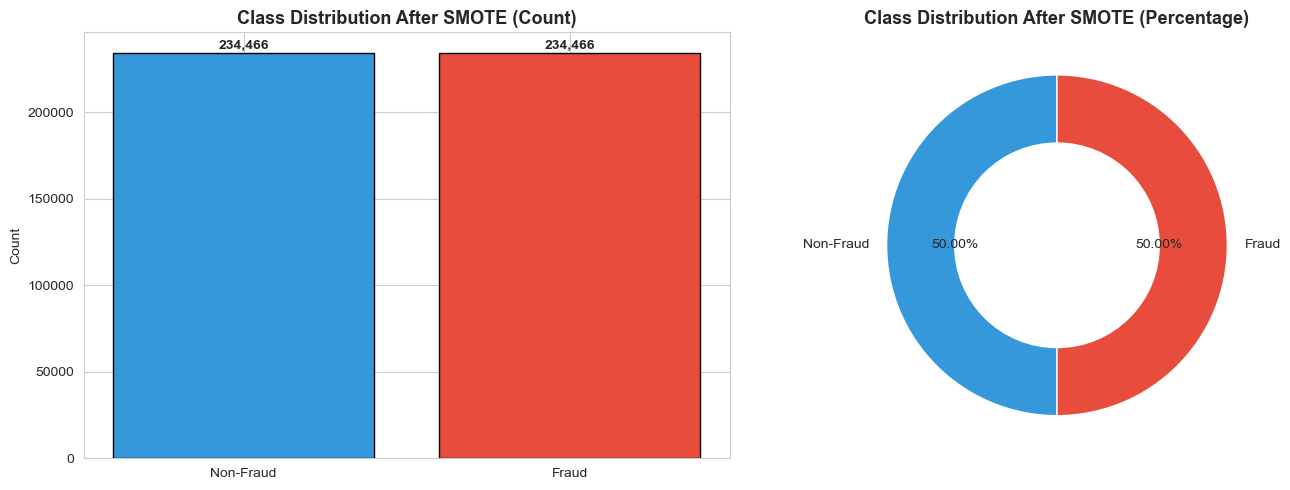

In [12]:
# Visualise class distribution AFTER SMOTE
after_counts = [(y_train_smote==0).sum(), (y_train_smote==1).sum()]
labels = ['Non-Fraud', 'Fraud']
colors = ['#3498db', '#e74c3c']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Bar chart ---
axes[0].bar(labels, after_counts, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution After SMOTE (Count)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(after_counts):
    axes[0].text(i, v + max(after_counts)*0.01, f'{v:,}', ha='center', fontweight='bold')

# --- Donut chart ---
axes[1].pie(after_counts, labels=labels, colors=colors, autopct='%1.2f%%',
            startangle=90, wedgeprops=dict(width=0.4, edgecolor='white'))
axes[1].set_title('Class Distribution After SMOTE (Percentage)', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

In [13]:
# Feature scaling (essential for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

print(" Features scaled using StandardScaler")
print(f"   Mean after scaling: {X_train_scaled.mean():.4f}")
print(f"   Std after scaling : {X_train_scaled.std():.4f}")

 Features scaled using StandardScaler
   Mean after scaling: 0.0000
   Std after scaling : 1.0000


## 6. Learning Methods

### Model 1 — Logistic Regression
**Algorithm:** Linear classifier that models the probability of fraud using a sigmoid function on a weighted sum of features.

In [14]:
# Train Logistic Regression
print("Training Logistic Regression model")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lr_model.fit(X_train_scaled, y_train_smote)

lr_train_time = time.time() - start_time
print(f" Logistic Regression trained in {lr_train_time:.2f} seconds")

Training Logistic Regression model
 Logistic Regression trained in 6.62 seconds


In [15]:
# Predict on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 60)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 60)

lr_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall'   : recall_score(y_test, y_pred_lr),
    'F1-Score' : f1_score(y_test, y_pred_lr),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_lr)
}

for metric, value in lr_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Non-Fraud', 'Fraud']))

LOGISTIC REGRESSION — EVALUATION
  Accuracy  : 0.9188
  Precision : 0.1837
  Recall    : 0.7791
  F1-Score  : 0.2973
  ROC-AUC   : 0.9262

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.92      0.96     58617
       Fraud       0.18      0.78      0.30      1322

    accuracy                           0.92     59939
   macro avg       0.59      0.85      0.63     59939
weighted avg       0.98      0.92      0.94     59939



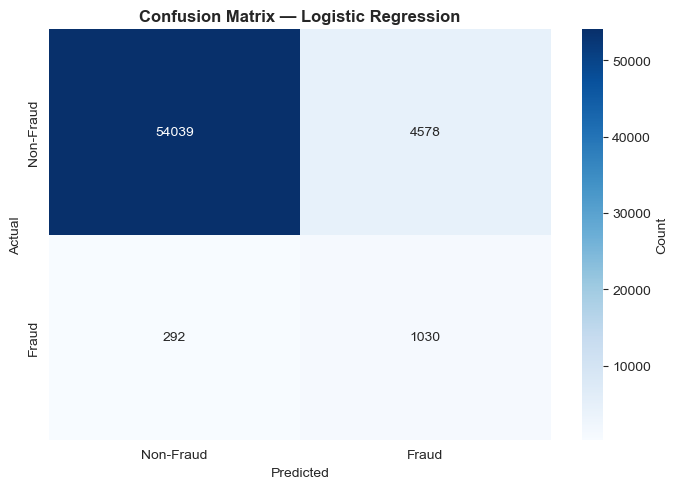

True Negatives : 54,039
False Positives: 4,578  (legitimate transactions flagged as fraud)
False Negatives: 292  (fraud missed)
True Positives : 1,030  (fraud correctly caught)


In [16]:
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Calculate detailed metrics
tn, fp, fn, tp = cm_lr.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate transactions flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

### Model 2: Naive Bayes
**Algorithm:** Probabilistic classifier based on Bayes' theorem, assuming features are independent given the class.

In [17]:
# Train Naive Bayes
from sklearn.naive_bayes import GaussianNB

print("Training Naive Bayes model")
start_time = time.time()

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train_smote)

nb_train_time = time.time() - start_time
print(f" Naive Bayes trained in {nb_train_time:.2f} seconds")

Training Naive Bayes model
 Naive Bayes trained in 0.52 seconds


In [18]:
# Predict on test set
y_pred_nb = nb_model.predict(X_test_scaled)
y_proba_nb = nb_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("=" * 60)
print("NAIVE BAYES — EVALUATION")
print("=" * 60)

nb_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_nb),
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall'   : recall_score(y_test, y_pred_nb),
    'F1-Score' : f1_score(y_test, y_pred_nb),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_nb)
}

for metric, value in nb_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Non-Fraud', 'Fraud']))

NAIVE BAYES — EVALUATION
  Accuracy  : 0.9185
  Precision : 0.1800
  Recall    : 0.7587
  F1-Score  : 0.2910
  ROC-AUC   : 0.9145

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.92      0.96     58617
       Fraud       0.18      0.76      0.29      1322

    accuracy                           0.92     59939
   macro avg       0.59      0.84      0.62     59939
weighted avg       0.98      0.92      0.94     59939



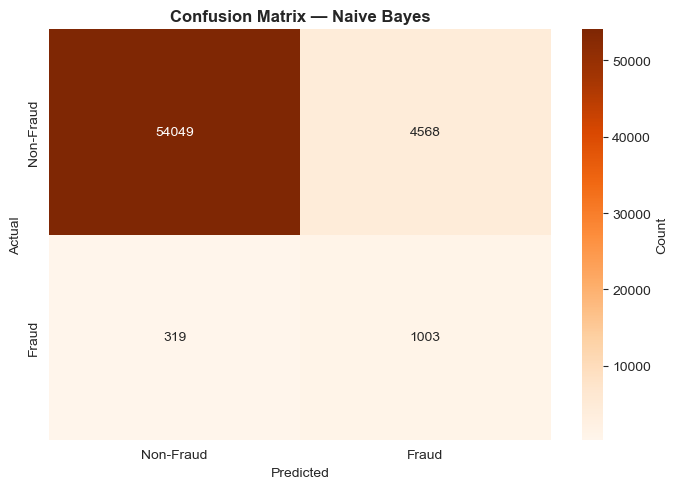

True Negatives : 54,049
False Positives: 4,568  (legitimate transactions flagged as fraud)
False Negatives: 319  (fraud missed)
True Positives : 1,003  (fraud correctly caught)


In [19]:
# Confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Naive Bayes', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Calculate detailed metrics
tn, fp, fn, tp = cm_nb.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate transactions flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

### Model 3: Random Forest
**Algorithm:** Ensemble of decision trees, each trained on a random sample of the data, with predictions combined through averaging.

In [20]:
# Train Random Forest

print("Training Random Forest model")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_smote, y_train_smote)

rf_train_time = time.time() - start_time
print(f" Random Forest trained in {rf_train_time:.2f} seconds")

Training Random Forest model
 Random Forest trained in 196.34 seconds


In [21]:
# Predict on test set
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=" * 60)
print("RANDOM FOREST — EVALUATION")
print("=" * 60)

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall'   : recall_score(y_test, y_pred_rf),
    'F1-Score' : f1_score(y_test, y_pred_rf),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_rf)
}

for metric, value in rf_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Fraud', 'Fraud']))

RANDOM FOREST — EVALUATION
  Accuracy  : 0.9815
  Precision : 0.5573
  Recall    : 0.7799
  F1-Score  : 0.6501
  ROC-AUC   : 0.9671

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     58617
       Fraud       0.56      0.78      0.65      1322

    accuracy                           0.98     59939
   macro avg       0.78      0.88      0.82     59939
weighted avg       0.99      0.98      0.98     59939



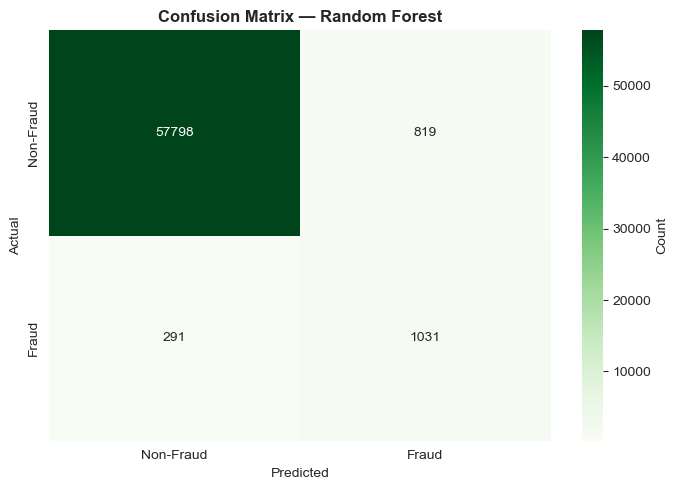

True Negatives : 57,798
False Positives: 819  (legitimate transactions flagged as fraud)
False Negatives: 291  (fraud missed)
True Positives : 1,031  (fraud correctly caught)


In [22]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Random Forest', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Calculate detailed metrics
tn, fp, fn, tp = cm_rf.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate transactions flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

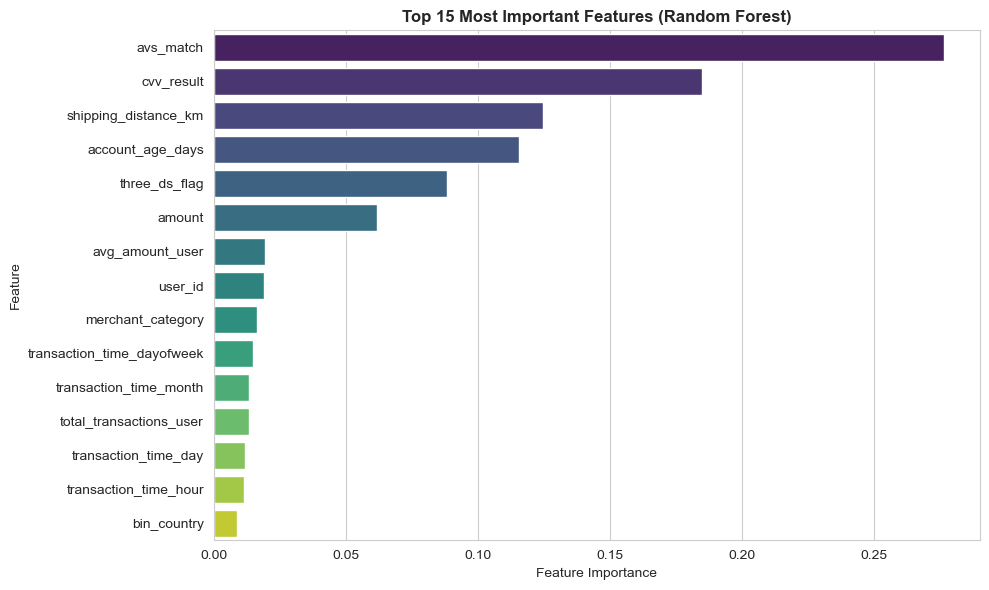


Top 10 features:
                   Feature  Importance
                 avs_match    0.276503
                cvv_result    0.184910
      shipping_distance_km    0.124828
          account_age_days    0.115630
             three_ds_flag    0.088355
                    amount    0.061716
           avg_amount_user    0.019315
                   user_id    0.019259
         merchant_category    0.016556
transaction_time_dayofweek    0.015055


In [23]:
# Feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Most Important Features (Random Forest)', fontweight='bold')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(feature_importance.head(10).to_string(index=False))


## Models Evaluation Summary

In [24]:
# Build comparison table for all 3 models
comparison_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Naïve Bayes'        : nb_metrics,
    'Random Forest'      : rf_metrics
}).T

print("=" * 70)
print("MODEL EVALUATION METRICS")
print("=" * 70)
print(comparison_df.round(4).to_string())
print()

# Identify best model per metric
print("\nBest model per metric:")
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric:10s}: {best_model} ({best_value:.4f})")

MODEL EVALUATION METRICS
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9188     0.1837  0.7791    0.2973   0.9262
Naïve Bayes            0.9185     0.1800  0.7587    0.2910   0.9145
Random Forest          0.9815     0.5573  0.7799    0.6501   0.9671


Best model per metric:
  Accuracy  : Random Forest (0.9815)
  Precision : Random Forest (0.5573)
  Recall    : Random Forest (0.7799)
  F1-Score  : Random Forest (0.6501)
  ROC-AUC   : Random Forest (0.9671)


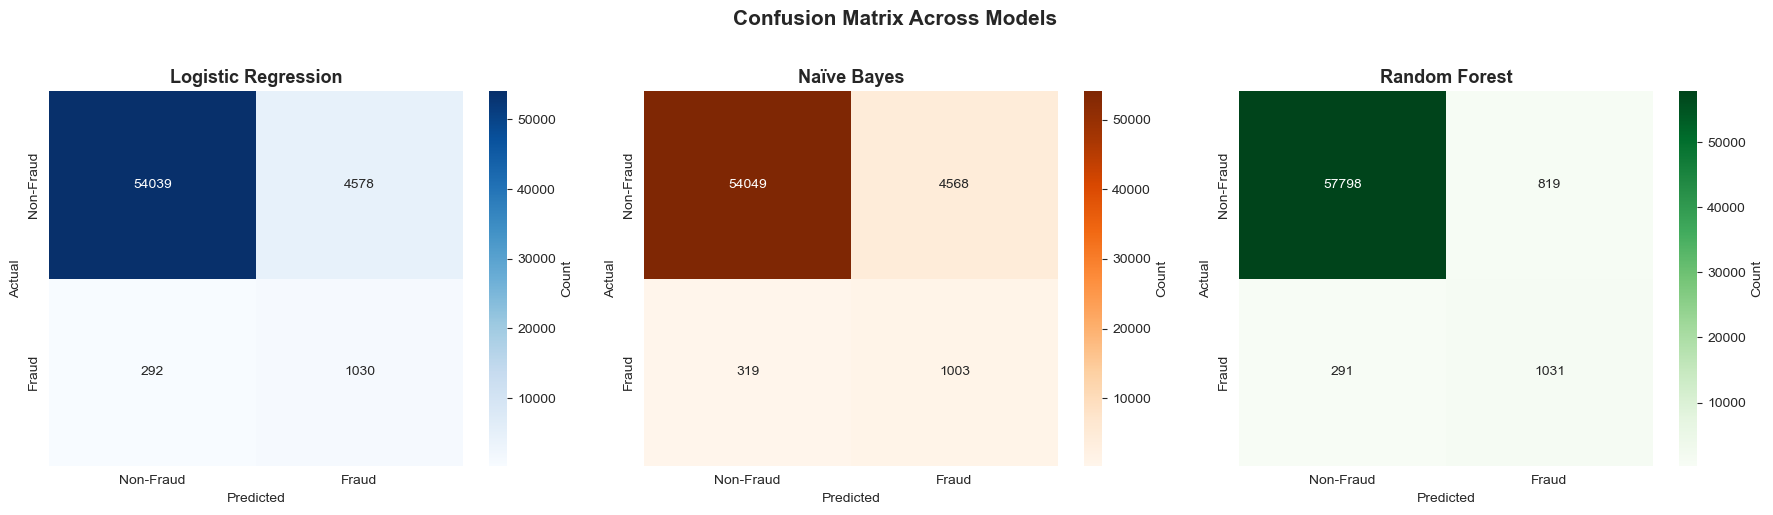

In [25]:
# Plot all 3 confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Logistic Regression', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Naïve Bayes
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Naïve Bayes', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Random Forest
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('Random Forest', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Across Models', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 8. Hyper-parameter Optimization

We use **GridSearchCV** with **5-fold stratified cross-validation** to find the best parameters for the models

**Justification:** GridSearchCV is exhaustive and reliable. Stratified K-fold preserves class distribution in each fold, which is critical for imbalanced data.

### Model 1: Tune Logistic Regression

In [26]:
# --- Hyper-parameter tuning for Logistic Regression ---
param_grid_lr = {
    'C'     : [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear']
}

print("Tuning Logistic Regression")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=param_grid_lr,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_lr.fit(X_train_scaled, y_train_smote)
print(f"\n Completed in {(time.time()-start)/60:.1f} minutes")
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV F1-Score: {grid_lr.best_score_:.4f}")

lr_tuned = grid_lr.best_estimator_

Tuning Logistic Regression
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Completed in 0.9 minutes
Best parameters: {'C': 0.01, 'solver': 'liblinear'}
Best CV F1-Score: 0.9257


In [27]:
# Predict on test set
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
y_proba_lr_tuned = lr_tuned.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("LOGISTIC REGRESSION (TUNED) — EVALUATION")
print("=" * 60)

lr_tuned_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_lr_tuned),
    'Precision': precision_score(y_test, y_pred_lr_tuned),
    'Recall'   : recall_score(y_test, y_pred_lr_tuned),
    'F1-Score' : f1_score(y_test, y_pred_lr_tuned),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_lr_tuned)
}

for metric, value in lr_tuned_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Non-Fraud', 'Fraud']))

cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

LOGISTIC REGRESSION (TUNED) — EVALUATION
  Accuracy  : 0.9188
  Precision : 0.1838
  Recall    : 0.7791
  F1-Score  : 0.2974
  ROC-AUC   : 0.9260

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.92      0.96     58617
       Fraud       0.18      0.78      0.30      1322

    accuracy                           0.92     59939
   macro avg       0.59      0.85      0.63     59939
weighted avg       0.98      0.92      0.94     59939



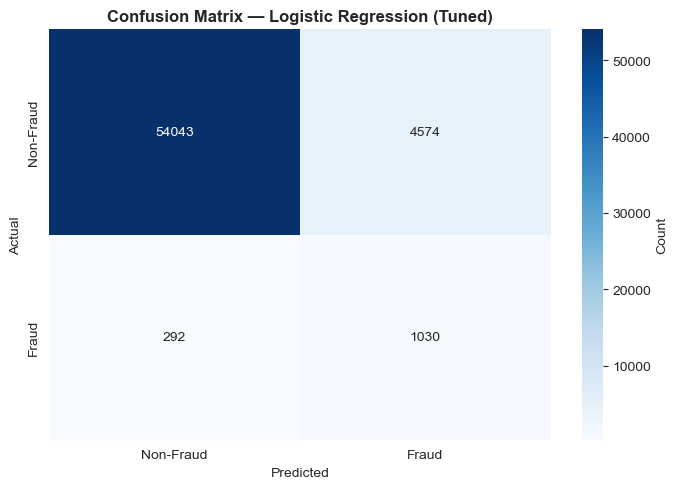

True Negatives : 54,043
False Positives: 4,574  (legitimate flagged as fraud)
False Negatives: 292  (fraud missed)
True Positives : 1,030  (fraud correctly caught)


In [39]:
# --- Confusion Matrix: Logistic Regression (Tuned) ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Logistic Regression (Tuned)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_lr_tuned.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

### Model 2: Tune Naive Bayes

In [28]:
# --- Hyper-parameter tuning for Naïve Bayes ---
param_grid_nb = {
    'var_smoothing': [1e-12, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6]
}

print("Tuning Naïve Bayes")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

start = time.time()
grid_nb.fit(X_train_scaled, y_train_smote)
print(f"\n Completed in {(time.time()-start)/60:.1f} minutes")
print(f"Best parameters: {grid_nb.best_params_}")
print(f"Best CV F1-score: {grid_nb.best_score_:.4f}")

nb_tuned = grid_nb.best_estimator_

Tuning Naïve Bayes
Fitting 5 folds for each of 6 candidates, totalling 30 fits

 Completed in 0.2 minutes
Best parameters: {'var_smoothing': 1e-12}
Best CV F1-score: 0.9221


In [33]:
# Predict on test set
y_pred_nb_tuned = nb_tuned.predict(X_test_scaled)
y_proba_nb_tuned = nb_tuned.predict_proba(X_test_scaled)[:, 1]

print("=" * 60)
print("NAÏVE BAYES (TUNED) — EVALUATION")
print("=" * 60)

nb_tuned_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_nb_tuned),
    'Precision': precision_score(y_test, y_pred_nb_tuned),
    'Recall'   : recall_score(y_test, y_pred_nb_tuned),
    'F1-Score' : f1_score(y_test, y_pred_nb_tuned),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_nb_tuned)
}

for metric, value in nb_tuned_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb_tuned, target_names=['Non-Fraud', 'Fraud']))

cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned)

NAÏVE BAYES (TUNED) — EVALUATION
  Accuracy  : 0.9185
  Precision : 0.1800
  Recall    : 0.7587
  F1-Score  : 0.2910
  ROC-AUC   : 0.9145

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.92      0.96     58617
       Fraud       0.18      0.76      0.29      1322

    accuracy                           0.92     59939
   macro avg       0.59      0.84      0.62     59939
weighted avg       0.98      0.92      0.94     59939



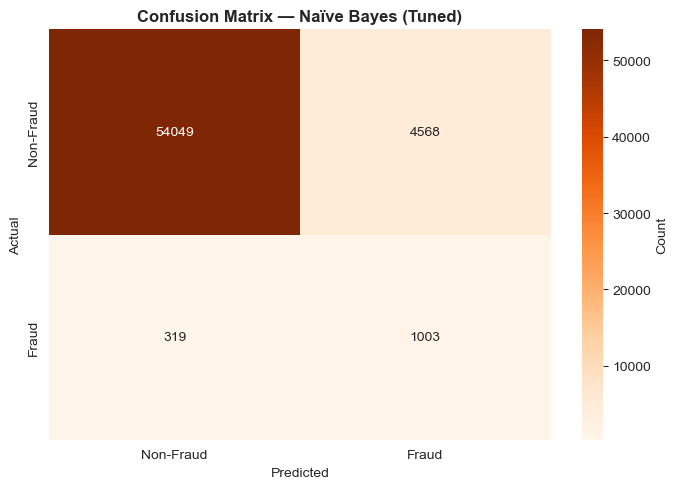

True Negatives : 54,049
False Positives: 4,568  (legitimate flagged as fraud)
False Negatives: 319  (fraud missed)
True Positives : 1,003  (fraud correctly caught)


In [40]:
# --- Confusion Matrix: Naïve Bayes (Tuned) ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb_tuned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Naïve Bayes (Tuned)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_nb_tuned.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

### Model 3: Tune Random Forest

In [46]:
# --- Hyper-parameter tuning for Random Forest ---

# Subsample 40% 
X_train_subsample, y_train_subsample = resample(
    X_train_smote, y_train_smote,
    n_samples=int(len(X_train_smote) * 0.4),
    random_state=RANDOM_STATE,
    stratify=y_train_smote
)

print(f"Original training set: {len(X_train_smote):,} samples")
print(f"Subsampled training set: {len(X_train_subsample):,} samples (40%)")

param_grid_rf = {
    'n_estimators': [50, 100]
}

print(f"\nTuning Random Forest")
print(f"Total combinations: 2")
print(f"With 5-fold stratified CV: 10 model fits")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=2
)

start = time.time()
grid_rf.fit(X_train_subsample, y_train_subsample)
print(f"\n Completed in {(time.time()-start)/60:.1f} minutes")
print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV F1-score: {grid_rf.best_score_:.4f}")

# Re-train the FINAL model on FULL training data with best parameters
print("\nRe-training the final model on the full training data")
rf_tuned = RandomForestClassifier(
    **grid_rf.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_tuned.fit(X_train_smote, y_train_smote)
print(" Final tuned Random Forest trained on full data!")

Original training set: 468,932 samples
Subsampled training set: 187,572 samples (40%)

Tuning Random Forest
Total combinations: 2
With 5-fold stratified CV: 10 model fits
Fitting 5 folds for each of 2 candidates, totalling 10 fits

 Completed in 6.3 minutes
Best parameters: {'n_estimators': 100}
Best CV F1-score: 0.9856

Re-training the final model on the full training data
 Final tuned Random Forest trained on full data!


In [38]:
# Predict on test set
y_pred_rf_tuned = rf_tuned.predict(X_test)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

print("=" * 60)
print("RANDOM FOREST (TUNED) — EVALUATION")
print("=" * 60)

rf_tuned_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf_tuned),
    'Precision': precision_score(y_test, y_pred_rf_tuned),
    'Recall'   : recall_score(y_test, y_pred_rf_tuned),
    'F1-Score' : f1_score(y_test, y_pred_rf_tuned),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba_rf_tuned)
}

for metric, value in rf_tuned_metrics.items():
    print(f"  {metric:10s}: {value:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Non-Fraud', 'Fraud']))

cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

RANDOM FOREST (TUNED) — EVALUATION
  Accuracy  : 0.9815
  Precision : 0.5573
  Recall    : 0.7799
  F1-Score  : 0.6501
  ROC-AUC   : 0.9671

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       0.99      0.99      0.99     58617
       Fraud       0.56      0.78      0.65      1322

    accuracy                           0.98     59939
   macro avg       0.78      0.88      0.82     59939
weighted avg       0.99      0.98      0.98     59939



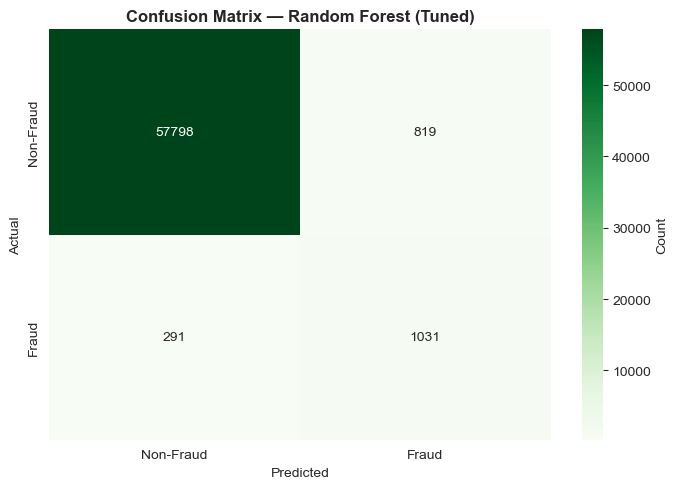

True Negatives : 57,798
False Positives: 819  (legitimate flagged as fraud)
False Negatives: 291  (fraud missed)
True Positives : 1,031  (fraud correctly caught)


In [41]:
# --- Confusion Matrix: Random Forest (Tuned) ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — Random Forest (Tuned)', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm_rf_tuned.ravel()
print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}  (legitimate flagged as fraud)")
print(f"False Negatives: {fn:,}  (fraud missed)")
print(f"True Positives : {tp:,}  (fraud correctly caught)")

### Tuned Models Evaluation Summary

In [43]:
# --- COMBINED Summary Table: All 3 Tuned Models ---
print("=" * 70)
print("MODEL COMPARISON — ALL TUNED MODELS")
print("=" * 70)

tuned_comparison = pd.DataFrame({
    'Logistic Regression (Tuned)': lr_tuned_metrics,
    'Naïve Bayes (Tuned)'        : nb_tuned_metrics,
    'Random Forest (Tuned)'      : rf_tuned_metrics
}).T

print(tuned_comparison.round(4).to_string())

# Identify best model per metric
print("\n" + "=" * 70)
print("BEST MODEL PER METRIC")
print("=" * 70)
for metric in tuned_comparison.columns:
    best_model = tuned_comparison[metric].idxmax()
    best_value = tuned_comparison[metric].max()
    print(f"  {metric:10s}: {best_model} ({best_value:.4f})")

MODEL COMPARISON — ALL TUNED MODELS
                             Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (Tuned)    0.9188     0.1838  0.7791    0.2974   0.9260
Naïve Bayes (Tuned)            0.9185     0.1800  0.7587    0.2910   0.9145
Random Forest (Tuned)          0.9815     0.5573  0.7799    0.6501   0.9671

BEST MODEL PER METRIC
  Accuracy  : Random Forest (Tuned) (0.9815)
  Precision : Random Forest (Tuned) (0.5573)
  Recall    : Random Forest (Tuned) (0.7799)
  F1-Score  : Random Forest (Tuned) (0.6501)
  ROC-AUC   : Random Forest (Tuned) (0.9671)


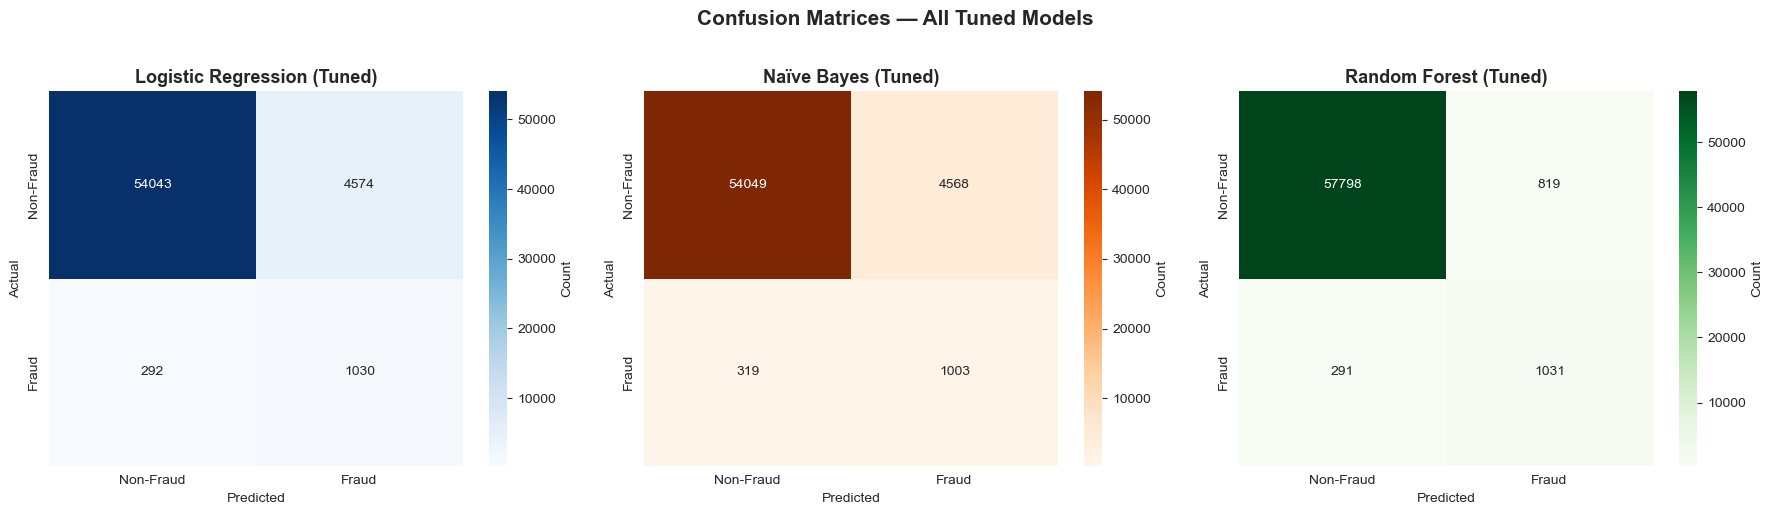

In [44]:
# --- Combined Confusion Matrices: All 3 Tuned Models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression (Tuned)
sns.heatmap(cm_lr_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title('Logistic Regression (Tuned)', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Naïve Bayes (Tuned)
sns.heatmap(cm_nb_tuned, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Naïve Bayes (Tuned)', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Random Forest (Tuned)
sns.heatmap(cm_rf_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Fraud', 'Fraud'],
            yticklabels=['Non-Fraud', 'Fraud'],
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title('Random Forest (Tuned)', fontweight='bold', fontsize=13)
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Tuned Models', fontweight='bold', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()